# Customer Churn Prediction

## Business Problem

Customer churn is one of the main challenges faced by telecommunications companies. Retaining existing customers is generally more cost-effective than acquiring new ones, making churn prediction an important business application of data science.

The objective of this project is to identify the factors associated with customer churn and develop predictive models capable of estimating the probability of customer churn.

To achieve this, the project follows a complete data science workflow, including data cleaning, exploratory data analysis (EDA), feature preprocessing, model training, and model evaluation.

Beyond building predictive models, this analysis aims to provide actionable business insights that can help improve customer retention strategies.

* What business actions could help reduce customer attrition?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")
pd.set_option('display.max_columns', None)


# Dataset Description

The dataset contains information on **7,043 customers** from a telecommunications company. Each row represents a single customer, while the columns describe different aspects of their relationship with the company.

The available features include:

* Customer demographics (e.g., gender, senior citizen status, partner, dependents)
* Services subscribed by the customer
* Contract information
* Billing and payment details
* Customer tenure
* Churn status

The target variable used for modeling is **Churn Value**, where:

* **0** indicates that the customer remained with the company.
* **1** indicates that the customer churned.

Before building predictive models, the dataset will be inspected to evaluate its structure, data types, and overall quality.


In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


This information will be used to identify the factors associated with customer churn and build predictive models.

## Data Cleaning

Before performing the exploratory analysis and model training, the dataset was reviewed to identify irrelevant atributes, potential sources of data leakage and quality issues.

Missing values were inspected to ensure data completeness. Additionally, several variables were removed because they either contained no predictive value or could introduce information that would not be available at prediction time.

In [ ]:
#Eliminación de columnas sin importancia
df = df.drop(columns=["CustomerID","Count"])
#Tambien se optó por eliminar columnas que puedan producir "data leakage" puesto que son variables que podrían hacer que el modelo no generalice bien.
df = df.drop(columns=["Churn Reason","Churn Score", "CLTV"])

`Total Charges` is also converted to a numeric variable, since this field may be read as text due to blanks or formatting issues.

In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(0, inplace=True)

/tmp/ipykernel_2422/1668996792.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(0, inplace=True)


In [ ]:
df.shape

(7043, 28)

In [ ]:
df.isnull().sum()

### Missing Values

The dataset contains no missing values in the variables selected for modeling.

Although the original dataset includes missing values in **Churn Reason**, this feature was removed because it is only available after a customer has already churned, making it unsuitable for predictive modeling.


### Feature Removal

The following variables were removed:

* `CustomerID`: Unique identifier with no predictive value.
* `Count`: Constant value for all observations.
* `Churn Score`: Variable directly related to churn outcomes and therefore a source of data leakage.
* `Churn Reason`: Information only available after the customer has already churned.
* `CLTV` (Customer Lifetime Value): Calculated using information that may indirectly contain future customer behavior.

Removing these variables helps ensure that the predictive models rely only on information that would realistically be available when making predictions.

# Feature Classification

To facilitate the exploratory analysis, the variables were divided into two groups:

* **Categorical variables**, which describe customer characteristics and service attributes.
* **Numerical variables**, which contain measurable quantities such as tenure and billing information.

This separation allows the application of appropriate visualization techniques and statistical analyses for each type of variable.


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

Now, let's re-evaluate the numerical and categorical columns after the type conversion.

In [ ]:
print("Updated Numerical Columns:")
print(num_cols)
print("\nUpdated Categorical Columns:")
print(cat_cols)

Updated Numerical Columns:
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']

Updated Categorical Columns:
['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']


*After completing the data cleaning process, the dataset was considered ready for exploratory analysis. The next step is to examine the distributions of the variables and identify potential patterns associated with customer churn.*

# Exploratory Data Analysis

Before proceeding to the modeling stage, an exploratory data analysis (EDA) was conducted to better understand the characteristics of the dataset and identify potential factors associated with customer churn.

Both categorical and numerical variables were analyzed to examine their distributions, detect patterns, and explore relationships with the target variable.

The insights obtained during this stage guided the feature selection process and helped formulate hypotheses that were later validated through bivariate analysis.


## Helper functions

To avoid code duplication and ensure consistent visualizations, helper functions were created to calculate and plot the churn rate for different categorical features. This approach improves code readability and makes the analysis easier to reproduce.

In [ ]:
def churn_rate_table(data, group_col, target_col="Churn Label"):
    """
    Calculates the churn rate (%) for each category of a given feature.

    Parameters:
        data (DataFrame): Input dataset.
        group_col (str): Feature to group by.
        target_col (str): Target column indicating churn.

    Returns:
        DataFrame: Table containing the number of churned customers,
        total customers, and churn rate for each category.
    """
    table = data.groupby([group_col, target_col]).size().unstack(fill_value=0)
    if "Yes" not in table.columns:
        table["Yes"] = 0
    table["Total"] = table.sum(axis=1)
    table["Churn_Rate"] = np.where(table["Total"] > 0, table["Yes"] / table["Total"] * 100, 0)
    return table.sort_values("Churn_Rate", ascending=False)

def plot_churn_rate(data, group_col, ax=None, order=None, title=None):
    rate_table = churn_rate_table(data, group_col)
    if order is None:
        order = rate_table.index.tolist()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=rate_table.reset_index(),
        x=group_col,
        y="Churn_Rate",
        order=order,
        ax=ax,
        color="#4C78A8",
    )
    ax.set_title(title or f"Churn Rate by {group_col}")
    ax.set_xlabel(group_col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=35)
    return ax

## Categorical Variables analysis

Categorical variables were analyzed to understand the composition of the customer base and identify potential patterns that may be associated with customer churn.

The following visualizations show the distribution of customer characteristics, subscribed services, contract types, and payment methods. Understanding these distributions provides valuable context for the subsequent churn analysis.
### Note

The variable **City** was excluded from the categorical analysis due to its high cardinality, containing more than 1,100 unique categories. Visualizing such a large number of categories would not provide meaningful insights and would reduce the interpretability of the analysis.

Similarly, **Lat Long** was not considered in the exploratory analysis, as geographic coordinates do not offer an intuitive interpretation in count-based visualizations and was not expected to be primary driver of customer churn.


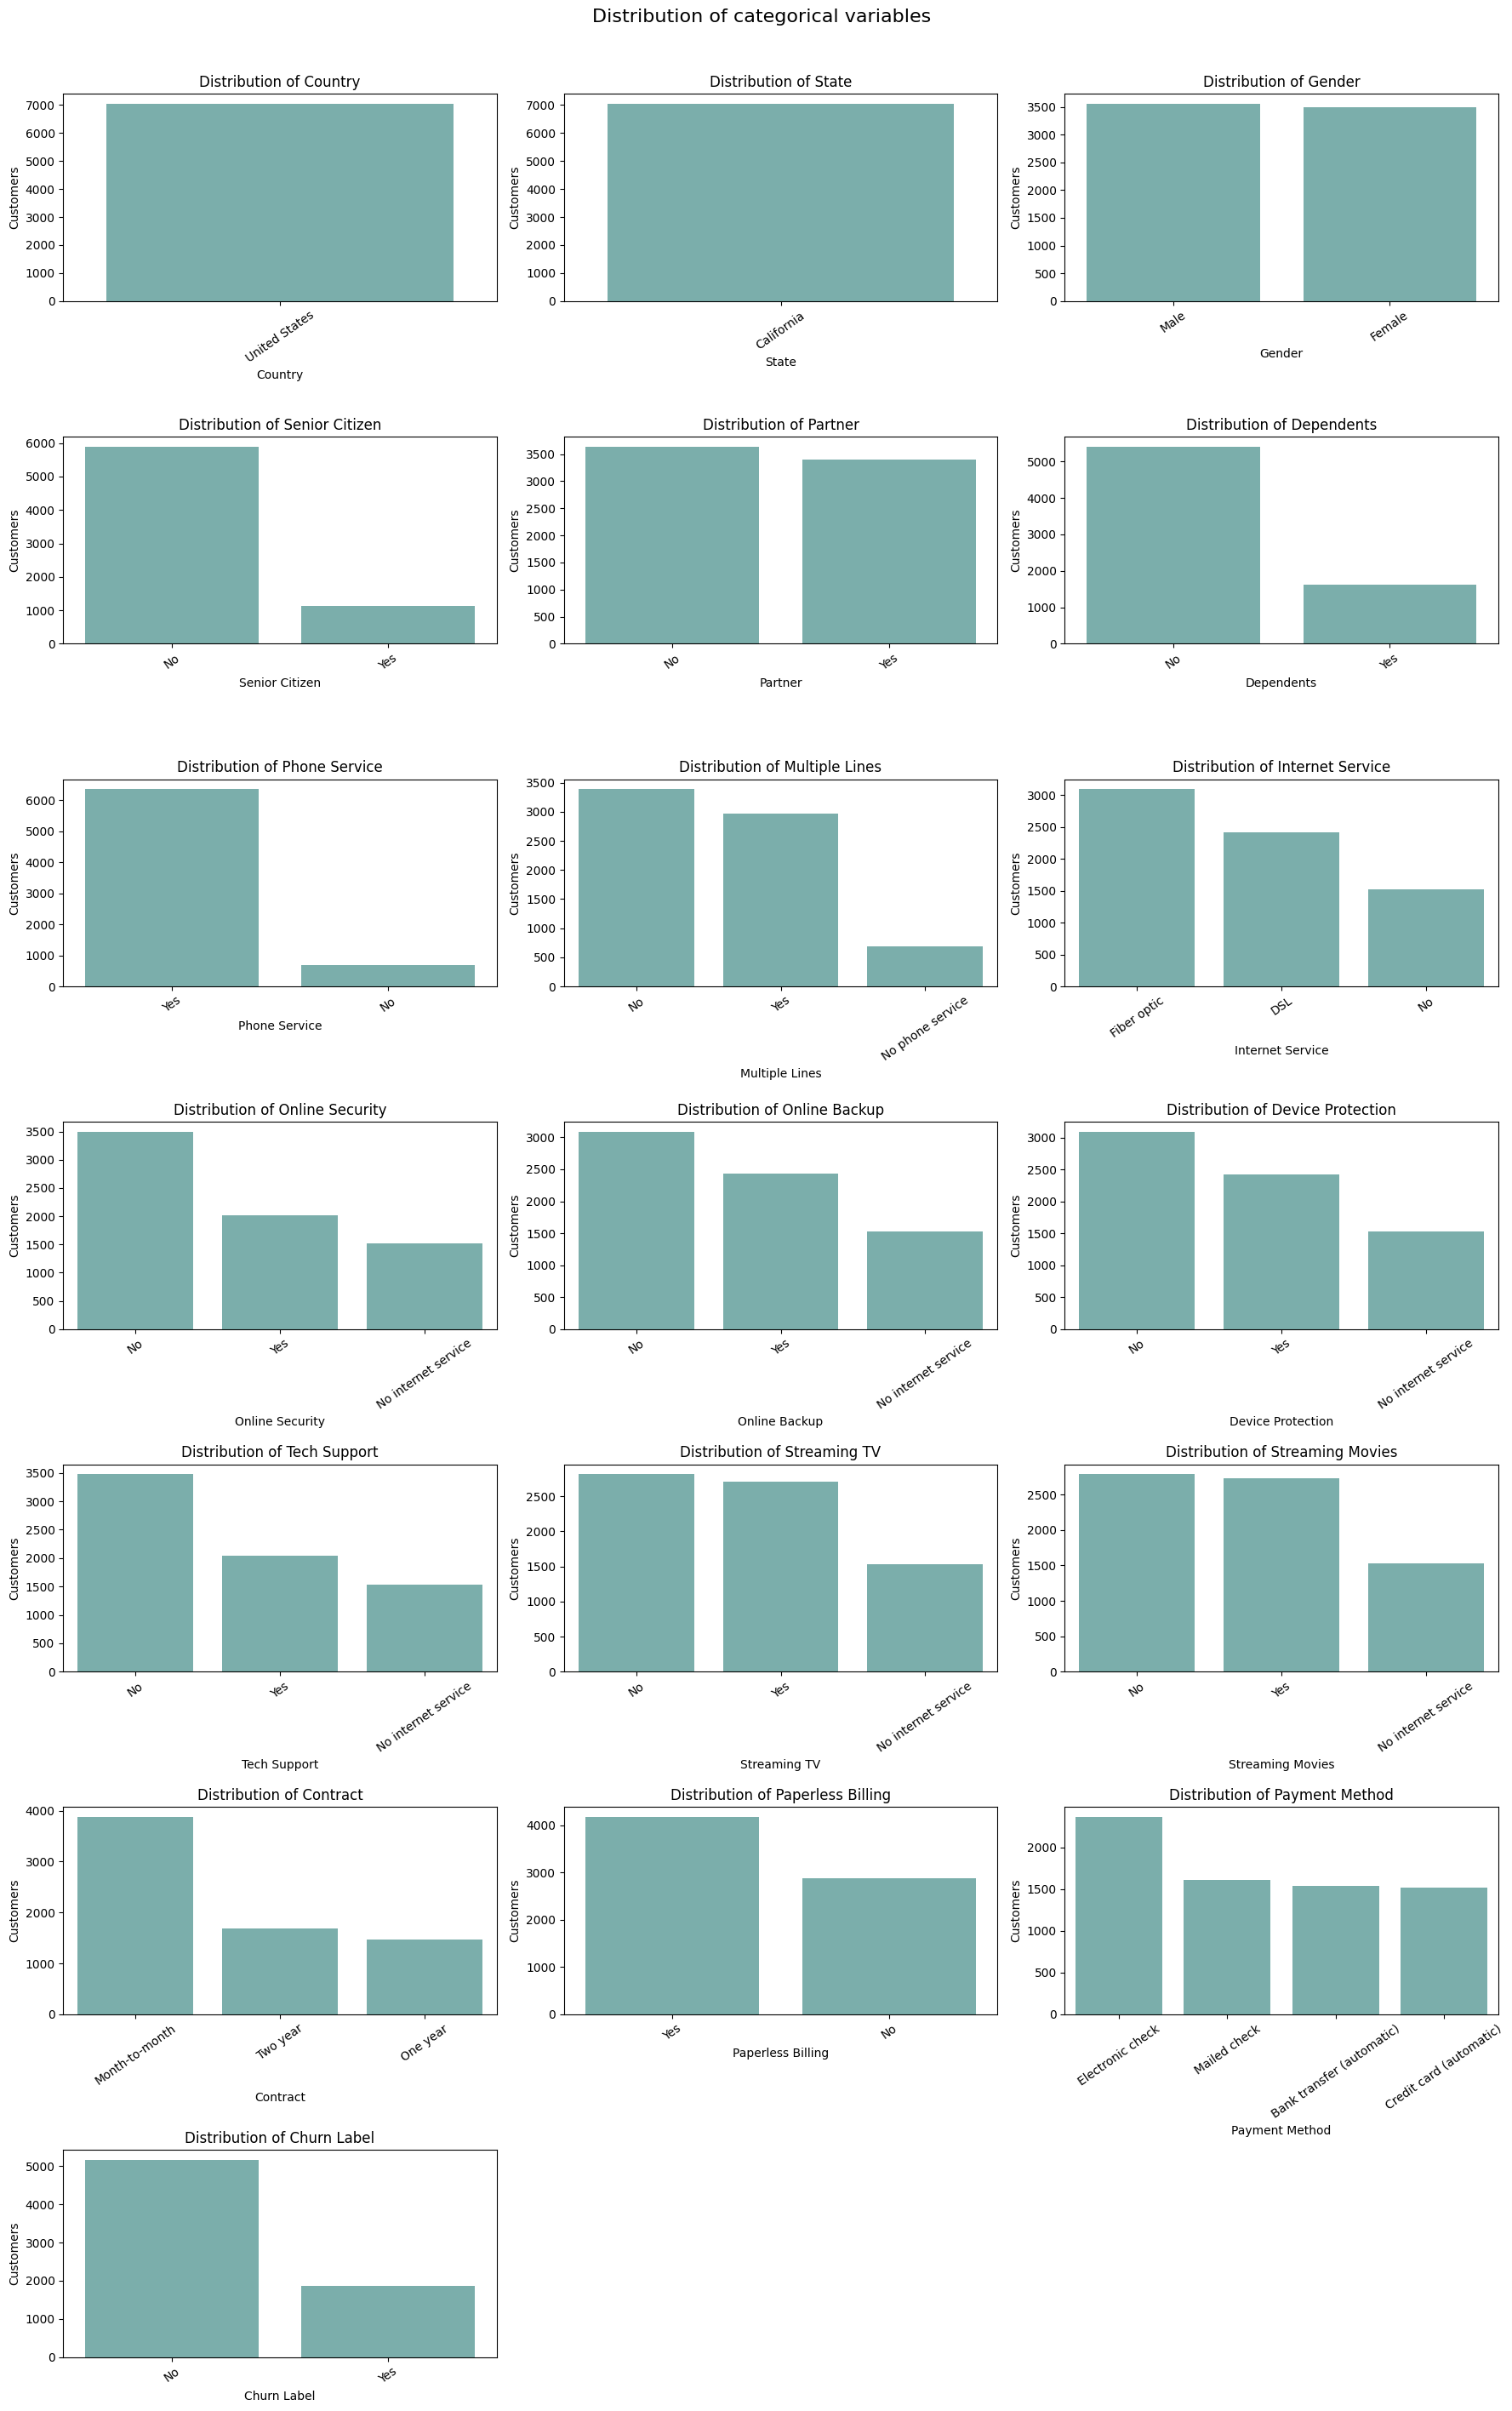

Note: The following columns were skipped due to high cardinality or uniform values: ['Lat Long', 'City']


In [ ]:
cols_to_skip = ["Lat Long", "City"]
# Filter cat_cols to exclude skipped columns
plottable_cat_cols = [col for col in cat_cols if col not in cols_to_skip]

n_cols = 3
n_rows = int(np.ceil(len(plottable_cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4, n_rows * 4)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plottable_cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color="#72B7B2")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x", rotation=35)

for ax in axes[len(plottable_cat_cols):]:
    ax.set_visible(False)

fig.suptitle("Distribution of categorical variables", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()

print(f"Note: The following columns were skipped due to high cardinality or uniform values: {cols_to_skip}")

### Key Findings

Several observations can be made from the categorical variables:

* The proportion of senior citizens is relatively low compared to the rest of the customer base.
* Most customers have phone service and internet-related services.
* Month-to-month contracts appear to be the most common contract type.
* The dataset contains a mix of customers with and without dependents and partners, allowing these factors to be explored further during the churn analysis.
* The target variable shows that customer churn represents approximately 26% of the observations, indicating a moderately imbalanced dataset.


## Numerical Variables analysis

After reviewing categorical columns, numerical atributes were review in order to understand how the data behaves.

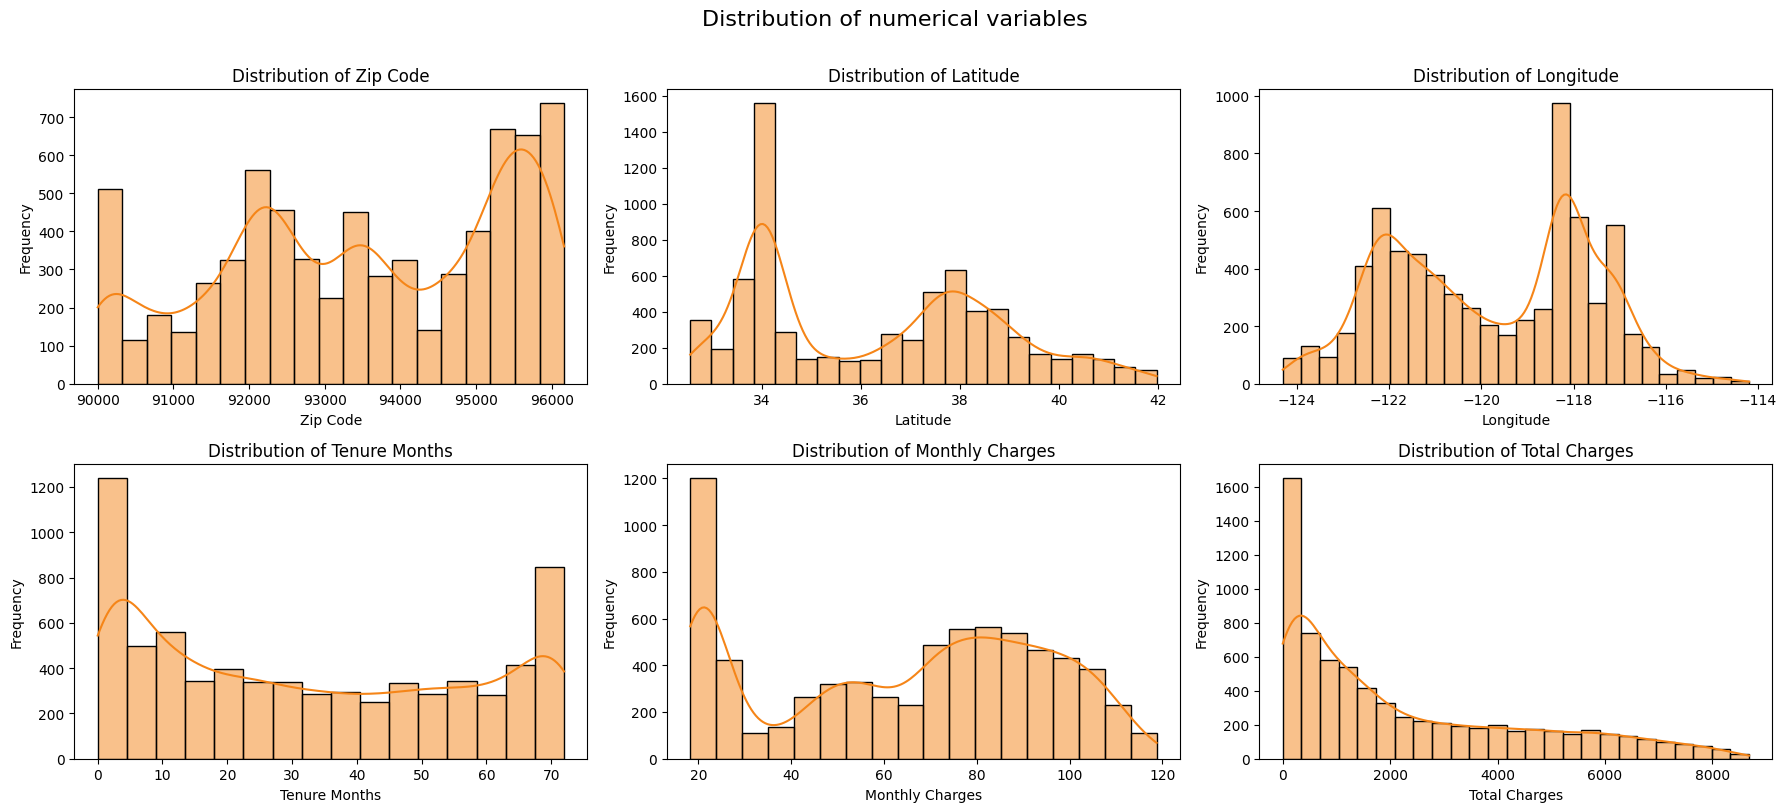

In [ ]:
plot_num_cols = [col for col in num_cols if col not in ["Churn Value"]]

n_cols = 3
n_rows = int(np.ceil(len(plot_num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4, n_rows * 4)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#F58518")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(plot_num_cols):]:
    ax.set_visible(False)

fig.suptitle("Distribution of numerical variables", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


## Correlation Analysis

To further explore the relationships between numerical variables, a correlation matrix was computed.

This analysis helps identify strong linear relationships between features, detect potential multicollinearity, and better understand how numerical variables interact before model training.

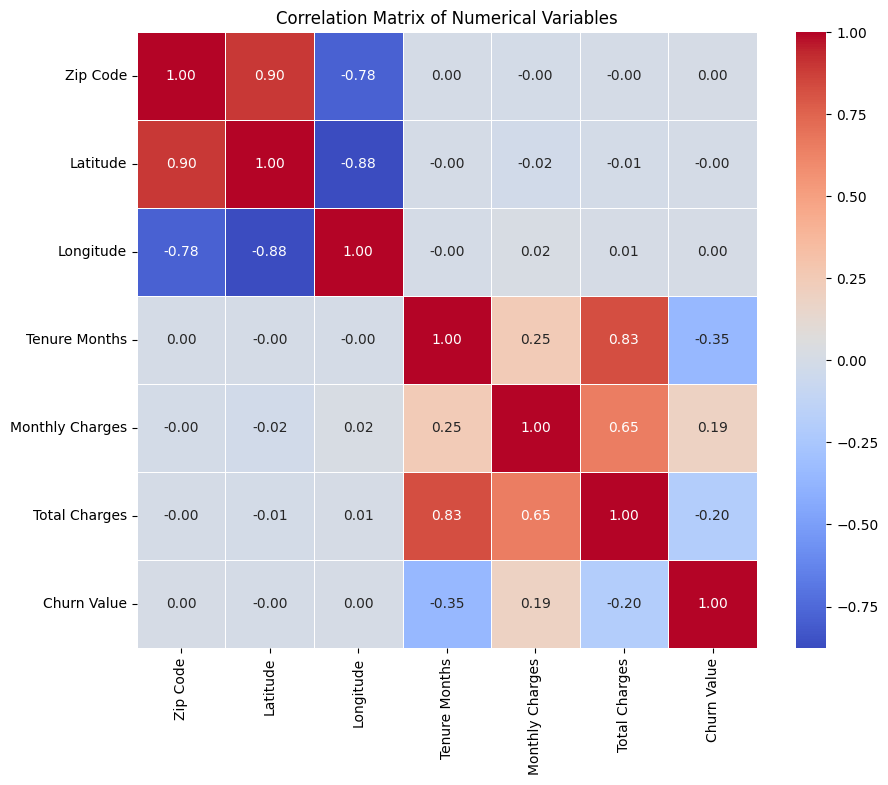

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

A strong positive correlation was observed between Tenure Months and Total Charges, which is expected since customers who remain with the company for longer periods naturally accumulate higher total charges.

No other strong correlations suggesting problematic multicollinearity were identified among the remaining numerical features.

## Hypothesis Testing

Based on the exploratory analysis, several hypotheses were formulated regarding the factors that may influence customer churn.

Each hypothesis is evaluated through bivariate analysis by comparing the selected features with the target variable (**Churn**). The objective is to determine whether the observed patterns support or contradict the initial assumptions.


This section evaluates a number of hypothesis established by comparing key variables against the target feature `Churn Label`

### Hypothesis 1

Customer with fewer services or missing support services are more like to churn.

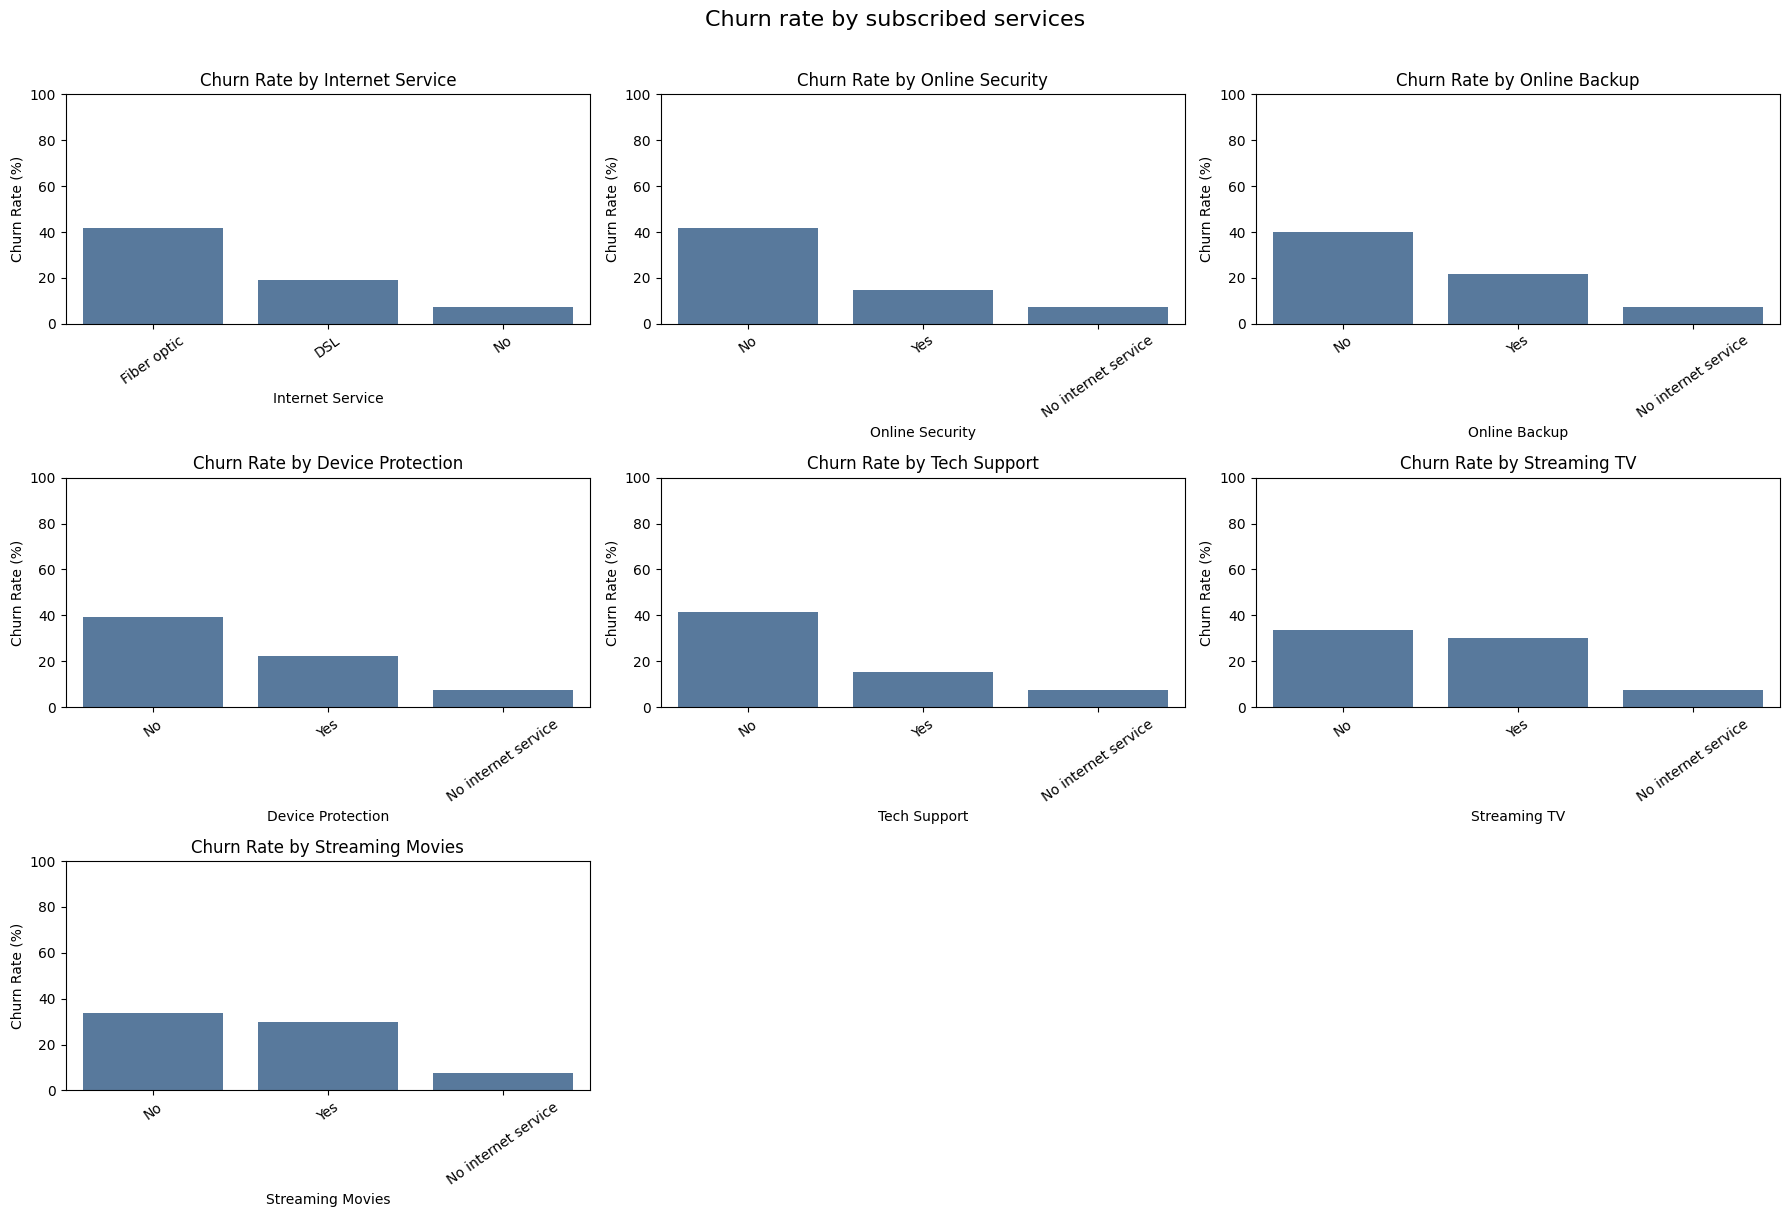

In [ ]:
service_cols = [
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
]
service_cols = [col for col in service_cols if col in df.columns]

n_cols = 3
n_rows = int(np.ceil(len(service_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4, n_rows * 4)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, service_cols):
    plot_churn_rate(df, col, ax=ax)

for ax in axes[len(service_cols):]:
    ax.set_visible(False)

fig.suptitle("Churn rate by subscribed services", y=1.01, fontsize=16)
fig.tight_layout()
plt.show()


Observation

The results support the initial hypothesis. Customers who do not subscribe to additional services such as Online Security, Online Backup, Device Protection, and Tech Support consistently exhibit higher churn rates.

These findings suggest that customers with fewer value-added services are less engaged with the company and therefore more likely to discontinue their subscription.

### Hypothesis 2

Customers with shorter tenure months are more likely to churn.

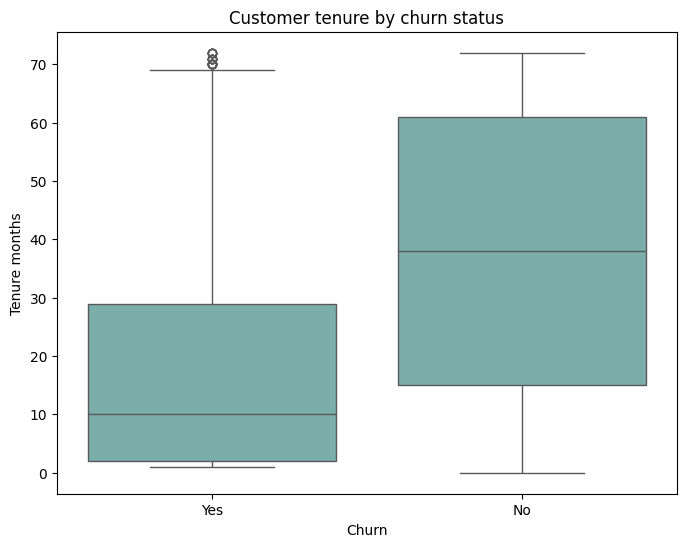

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Churn Label", y="Tenure Months", color="#72B7B2")
plt.title("Customer tenure by churn status")
plt.xlabel("Churn")
plt.ylabel("Tenure months")
plt.show()


#### Complementary graphic


/tmp/ipykernel_2422/4208632525.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby([group_col, target_col]).size().unstack(fill_value=0)


<Figure size 1400x600 with 0 Axes>

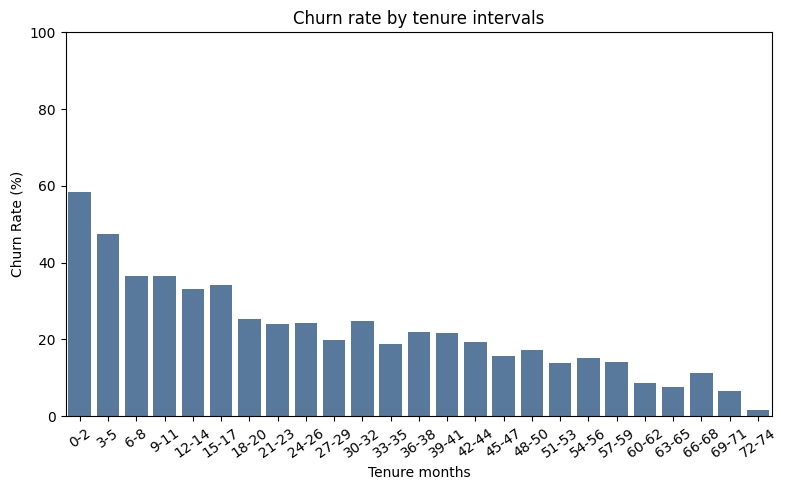

In [ ]:
bin_size = 3
max_tenure = int(df["Tenure Months"].max())
bins = list(range(0, max_tenure + bin_size + 1, bin_size))
labels = [f"{start}-{start + bin_size - 1}" for start in bins[:-1]]

df["Tenure_Months_Binned"] = pd.cut(
    df["Tenure Months"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)

plt.figure(figsize=(14, 6))
plot_churn_rate(
    df.dropna(subset=["Tenure_Months_Binned"]),
    "Tenure_Months_Binned",
    order=labels,
)
plt.title("Churn rate by tenure intervals")
plt.xlabel("Tenure months")
plt.tight_layout()
plt.show()

Observation

The analysis strongly supports the hypothesis. Customers with shorter tenure exhibit substantially higher churn rates, particularly during the first months of their subscription.

As customer tenure increases, the churn rate decreases considerably, suggesting that the early stages of the customer lifecycle are critical for retention efforts.

### Hypothesis 3

Customers with lower accumulated charges are more likely to churn

/tmp/ipykernel_2422/1650397854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y='Total Charges', palette='magma')


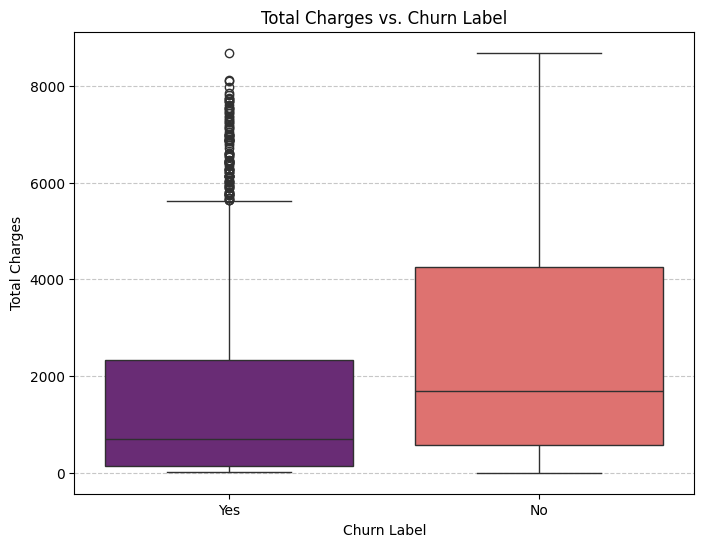

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn Label', y='Total Charges', palette='magma')
plt.title('Total Charges vs. Churn Label')
plt.xlabel('Churn Label')
plt.ylabel('Total Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation

Customers with lower accumulated charges tend to exhibit higher churn rates.

However, this relationship is likely influenced by customer tenure, as customers who have recently joined the company naturally accumulate lower total charges. Consequently, Tenure Months appears to be a more informative predictor than Total Charges.

### Hypothesis 4

Contract type, payment method, partner status, and dependents are related to churn rate

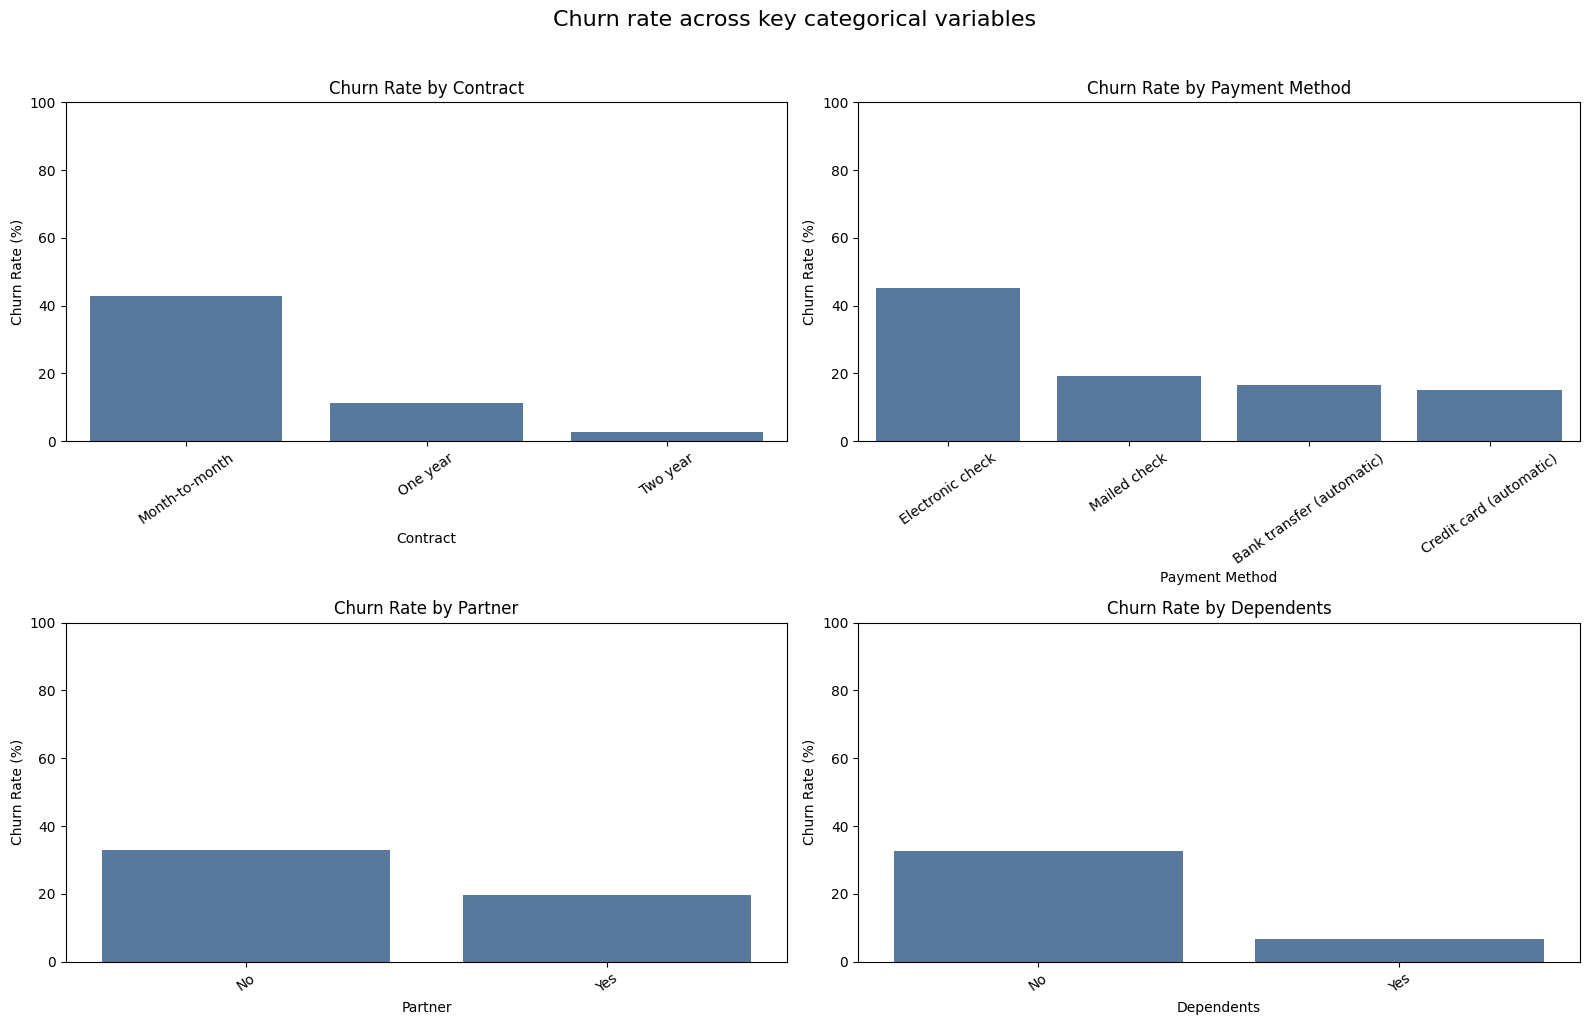

In [ ]:
key_cat_cols = ["Contract", "Payment Method", "Partner", "Dependents"]
key_cat_cols = [col for col in key_cat_cols if col in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.reshape(-1)

for ax, col in zip(axes, key_cat_cols):
    plot_churn_rate(df, col, ax=ax)

for ax in axes[len(key_cat_cols):]:
    ax.set_visible(False)

fig.suptitle("Churn rate across key categorical variables", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

Observation:

The analysis indicates that customer churn is closely related to contract type, payment method, partner status, and dependents.

Customers with month-to-month contracts exhibit the highest churn rates, while those with one-year and especially two-year contracts are significantly more likely to remain with the company.

In addition, customers using Electronic Check as their payment method show noticeably higher churn rates. Finally, customers without a partner and without dependents tend to churn more frequently than those with stronger household commitments.


## EDA Summary

The exploratory analysis identified several factors strongly associated with customer churn.

Among all the analyzed features, Tenure Months, Contract Type, Dependents, Internet Service, and value-added services such as Online Security and Tech Support showed the strongest relationships with the target variable.

These findings provide valuable business insights while also supporting the feature selection process for the predictive models developed in the following sections.

## Modeling Dataset Preparation

High-cardinality geographic information and fields not prioritized for the first modeling iteration are removed. The target variable is `Churn Value`, so `Churn Label` is excluded to avoid duplicating the target.

Before training the machine learning models, the dataset was prepared by removing non-informative features and transforming categorical variables into a numerical format.

These preprocessing steps ensure that the dataset is suitable for machine learning algorithms while preserving the information required for prediction.


### Column Removal

The following variables were removed from the dataset before the modeling stage:

* **Country:** Contains only a single value ("United States"), providing no predictive information.
* **State:** Contains only one value ("California") for all observations.
* **Lat Long:** Removed because it is redundant with the separate **Latitude** and **Longitude** variables.
* **Churn Label:** Removed since **Churn Value** was selected as the target variable for modeling.
* **City:** Excluded due to its high cardinality, with **1,129 unique cities** across approximately 7,000 observations.
* **Latitude**, **Longitude**, and **Zip Code:** Excluded because this project does not focus on geographical analysis, and these variables were not expected to provide meaningful predictive value for customer churn.


In [ ]:
model_drop_cols = [
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Tenure_Months_Binned",
    "City",
    "Latitude",
    "Longitude",
    "Zip Code",
]

df_model = df.drop(columns=model_drop_cols, errors="ignore").copy()
print(df_model.shape)
df_model.head()

(7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [ ]:
df_model.nunique().sort_values()

,0
Gender,2
Senior Citizen,2
Partner,2
Dependents,2
Phone Service,2
Paperless Billing,2
Churn Value,2
Internet Service,3
Tech Support,3
Online Security,3


### Encoding Categorical Variables

Machine learning algorithms require numerical input features. Therefore, categorical variables were transformed using One-Hot Encoding, creating binary indicator variables for each category.

This approach avoids introducing artificial ordinal relationships between categories, which could occur if arbitrary numerical labels were assigned.

In [ ]:
binary_mappings = {
    "Gender": {"Female": 0, "Male": 1},
    "Senior Citizen": {"No": 0, "Yes": 1},
    "Partner": {"No": 0, "Yes": 1},
    "Dependents": {"No": 0, "Yes": 1},
    "Phone Service": {"No": 0, "Yes": 1},
    "Paperless Billing": {"No": 0, "Yes": 1},
}

multi_category_cols = [
    "Internet Service",
    "Tech Support",
    "Online Security",
    "Device Protection",
    "Online Backup",
    "Streaming Movies",
    "Streaming TV",
    "Contract",
    "Multiple Lines",
    "Payment Method",
]

df_encoded = df_model.copy()

for col, mapping in binary_mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)

multi_category_cols = [col for col in multi_category_cols if col in df_encoded.columns]
df_encoded = pd.get_dummies(df_encoded, columns=multi_category_cols, drop_first=True, dtype=int)

df_encoded.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,Internet Service_Fiber optic,Internet Service_No,Tech Support_No internet service,Tech Support_Yes,Online Security_No internet service,Online Security_Yes,Device Protection_No internet service,Device Protection_Yes,Online Backup_No internet service,Online Backup_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Streaming TV_No internet service,Streaming TV_Yes,Contract_One year,Contract_Two year,Multiple Lines_No phone service,Multiple Lines_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
1,0,0,0,1,2,1,1,70.70,151.65,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,8,1,1,99.65,820.50,1,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0
3,0,0,1,1,28,1,1,104.80,3046.05,1,1,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0
4,1,0,0,1,49,1,1,103.70,5036.30,1,1,0,0,0,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0


## Model Training and Evaluation

Two supervised machine learning algorithms were evaluated to predict customer churn.

The objective was not only to compare predictive performance but also to assess the interpretability of each model and identify the factors most strongly associated with customer churn.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("Churn Value", axis=1)
y = df_encoded["Churn Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numerical_features = [col for col in ["Tenure Months", "Monthly Charges", "Total Charges"] if col in X.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)




Train: (5634, 30)
Test: (1409, 30)


In [ ]:
def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    accuracy = accuracy_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred, pos_label=1)
    cm = confusion_matrix(y_test_data, y_pred)

    print(f"{model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Churn class recall: {recall:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No churn", "Churn"],
        yticklabels=["No churn", "Churn"],
    )
    plt.title(f"Confusion matrix - {model_name}")
    plt.xlabel("Prediction")
    plt.ylabel("Actual value")
    plt.show()

    return {"Model": model_name, "Accuracy": accuracy, "Churn_Recall": recall}


### Logistic Regression

Logistic Regression was selected as the baseline model because it is a simple, interpretable, and widely used algorithm for binary classification problems.

In addition to providing competitive predictive performance, Logistic Regression allows the interpretation of feature coefficients, making it possible to understand how each variable influences the probability of customer churn.

Logistic Regression
Accuracy: 0.8020
Churn class recall: 0.5722


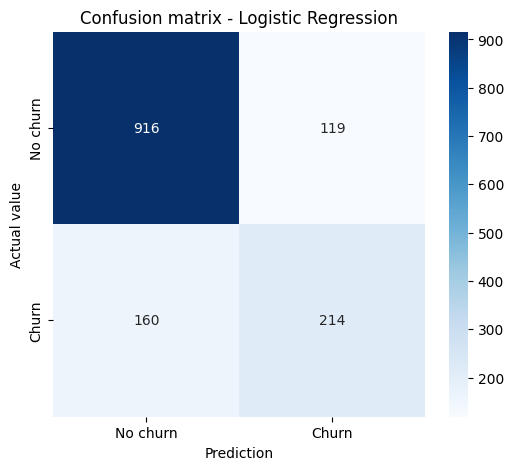

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_results = evaluate_model(log_model, X_test_scaled, y_test, "Logistic Regression")

In [ ]:
coefficients_df = (
    pd.DataFrame({
        "Feature": X_train_scaled.columns,
        "Coefficient": log_model.coef_[0],
    })
    .assign(Absolute_Coefficient=lambda x: x["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
)

coefficients_df.head(10)


,Feature,Coefficient,Absolute_Coefficient
3,Dependents,-1.614467,1.614467
24,Contract_Two year,-1.287759,1.287759
4,Tenure Months,-1.266460,1.266460
9,Internet Service_Fiber optic,1.083886,1.083886
23,Contract_One year,-0.719409,0.719409
8,Total Charges,0.514960,0.514960
5,Phone Service,-0.493098,0.493098
7,Monthly Charges,-0.407220,0.407220
28,Payment Method_Electronic check,0.373266,0.373266
26,Multiple Lines_Yes,0.368688,0.368688


### Random Forest

To compare the baseline model with a more flexible algorithm, a Random Forest classifier was also trained.

Random Forest is an ensemble learning method capable of capturing complex and non-linear relationships between variables without requiring feature standardization.


Random Forest
Accuracy: 0.7949
Churn class recall: 0.5027


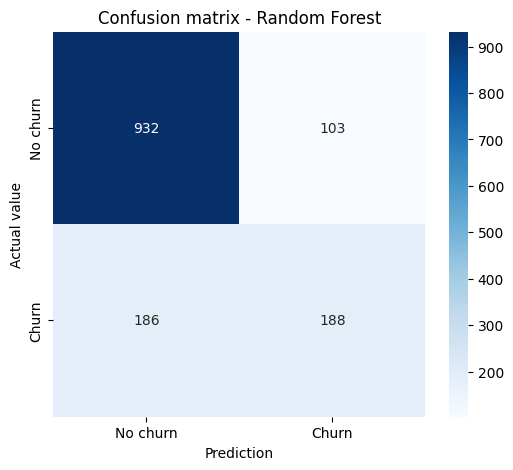

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)

rf_results = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")


In [ ]:
feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train_scaled.columns,
        "Importance": rf_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
)

feature_importance_df.head(10)

,Feature,Importance
8,Total Charges,0.167781
4,Tenure Months,0.162314
7,Monthly Charges,0.146095
24,Contract_Two year,0.054203
3,Dependents,0.053266
9,Internet Service_Fiber optic,0.046522
28,Payment Method_Electronic check,0.035308
23,Contract_One year,0.027519
14,Online Security_Yes,0.024949
0,Gender,0.024488


## Model Comparison

Two classification algorithms were evaluated: Logistic Regression and Random Forest.

Although both models achieved similar overall accuracy, Logistic Regression obtained a higher recall for the churn class while also providing greater interpretability through its feature coefficients.

Considering both predictive performance and model interpretability, Logistic Regression was selected as the final model for this project.

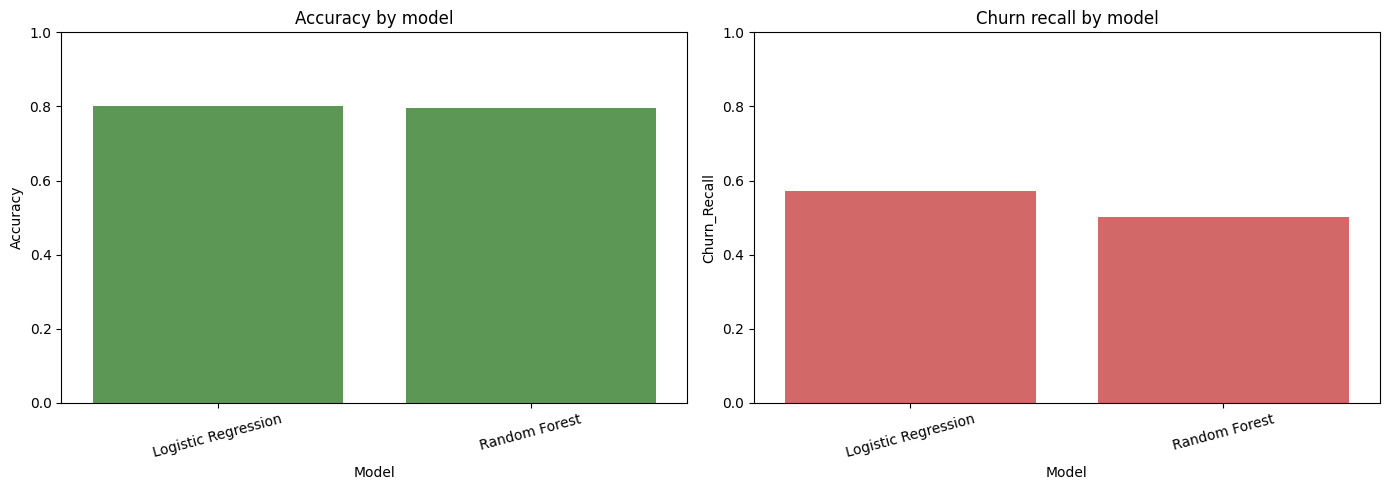

In [ ]:
model_comparison = pd.DataFrame([log_results, rf_results])
model_comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=model_comparison, x="Model", y="Accuracy", ax=axes[0], color="#54A24B")
axes[0].set_title("Accuracy by model")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=model_comparison, x="Model", y="Churn_Recall", ax=axes[1], color="#E45756")
axes[1].set_title("Churn recall by model")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

In [ ]:
print("Top 10 feature importances - Random Forest")
display(feature_importance_df.head(10))

print("\nTop 10 absolute coefficients - Logistic Regression")
display(coefficients_df.head(10))


Top 10 feature importances - Random Forest


,Feature,Importance
8,Total Charges,0.167781
4,Tenure Months,0.162314
7,Monthly Charges,0.146095
24,Contract_Two year,0.054203
3,Dependents,0.053266
9,Internet Service_Fiber optic,0.046522
28,Payment Method_Electronic check,0.035308
23,Contract_One year,0.027519
14,Online Security_Yes,0.024949
0,Gender,0.024488



Top 10 absolute coefficients - Logistic Regression


,Feature,Coefficient,Absolute_Coefficient
3,Dependents,-1.614467,1.614467
24,Contract_Two year,-1.287759,1.287759
4,Tenure Months,-1.266460,1.266460
9,Internet Service_Fiber optic,1.083886,1.083886
23,Contract_One year,-0.719409,0.719409
8,Total Charges,0.514960,0.514960
5,Phone Service,-0.493098,0.493098
7,Monthly Charges,-0.407220,0.407220
28,Payment Method_Electronic check,0.373266,0.373266
26,Multiple Lines_Yes,0.368688,0.368688


# Business Recommendations

The results of the exploratory analysis and predictive models suggest several actions that could help reduce customer churn.

These recommendations are intended to support customer retention strategies and improve long-term customer loyalty.

Based on the exploratory analysis and predictive models, several actions could help reduce customer churn:

* Prioritize retention campaigns during the first months of the customer lifecycle, when churn risk is highest.
* Encourage customers to migrate from month-to-month contracts to longer-term contracts.
* Promote value-added services such as **Online Security**, **Online Backup**, and **Tech Support**, which are associated with lower churn rates.
* Closely monitor customers using **Electronic Check**, as they exhibit higher churn rates.
* Develop personalized retention strategies for customers without partners or dependents, who appear more likely to churn.


## Conclusions

This project followed a complete machine learning workflow, from data cleaning and exploratory data analysis to predictive modeling and business interpretation.

The analysis identified Tenure Months, Contract Type, Dependents, and several value-added services as the variables most strongly associated with customer churn.

Among the evaluated models, Logistic Regression achieved the best balance between predictive performance and interpretability, making it the preferred model for this problem.

Beyond prediction, the results provide actionable business insights that can support customer retention strategies and improve long-term customer loyalty.